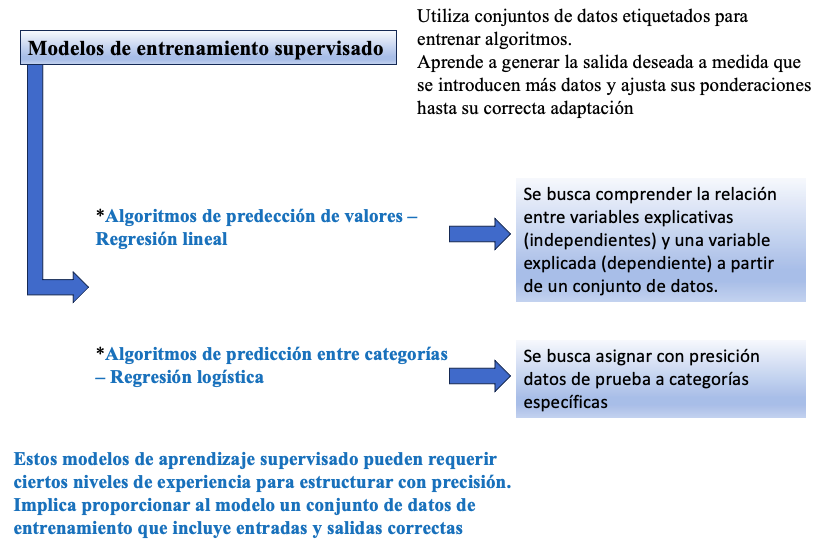

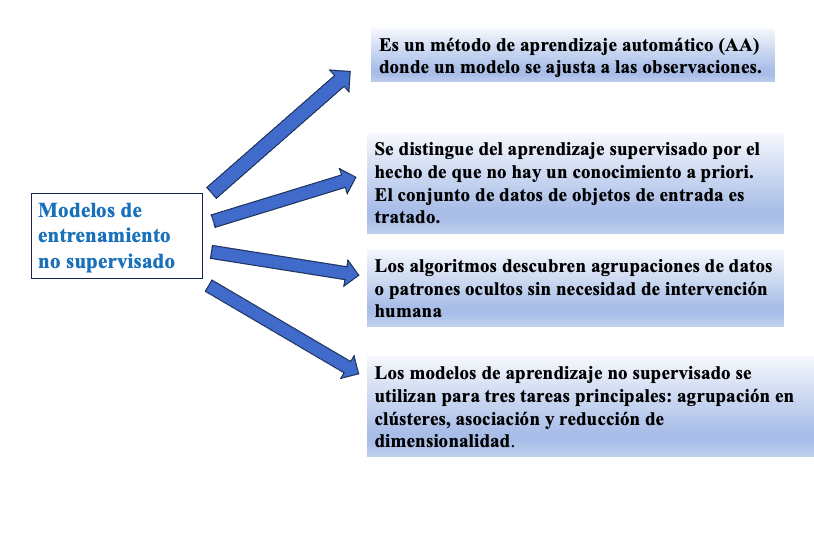

Entrenamiento Supervisado

Algoritmos de predicción de valores - Regresión lineal

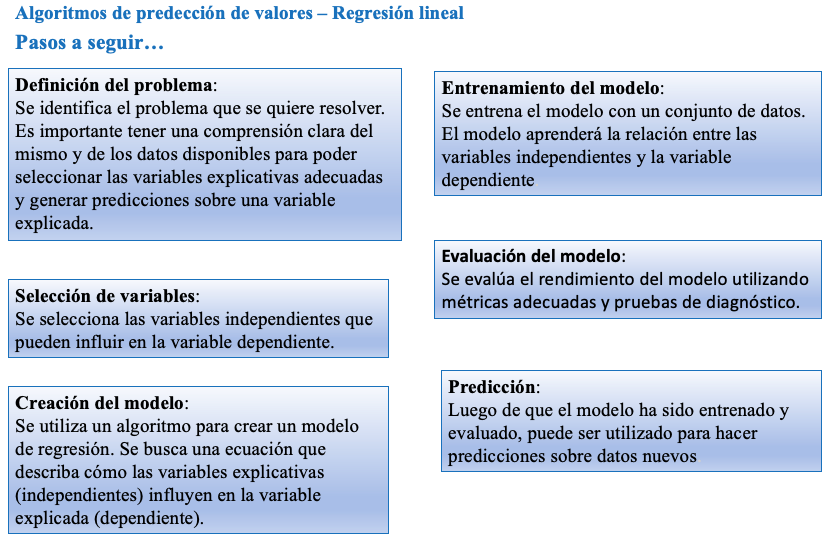

Ejemplo 1

---



In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para gráficos
sns.set_palette("husl")

# Descargar datos financieros de Yahoo Finance
def descargar_datos(ticker, inicio, fin):
    """
    Descarga datos históricos de Yahoo Finance
    """
    datos = yf.download(ticker, start=inicio, end=fin)
    return datos

# Ejemplo: Datos de Apple (AAPL) y del S&P 500 (^GSPC) como variable explicativa
inicio = '2020-01-01'
fin = '2023-12-31'

# Descargar datos
print("Descargando datos de AAPL y S&P 500...")
aapl = descargar_datos('AAPL', inicio, fin)
sp500 = descargar_datos('^GSPC', inicio, fin)

# Preparar los datos

datos = pd.DataFrame({
    'AAPL_Close': aapl['Close'].squeeze(),  # convertimos a series
    'SP500_Close': sp500['Close'].squeeze() # convertimos a series
}, index=aapl.index).dropna()

# Calcular retornos diarios
datos['AAPL_Retorno'] = datos['AAPL_Close'].pct_change() * 100
datos['SP500_Retorno'] = datos['SP500_Close'].pct_change() * 100
datos = datos.dropna()

datos

/tmp/ipykernel_5008/2631902033.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5008/2631902033.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed

Descargando datos de AAPL y S&P 500...


,AAPL_Close,SP500_Close,AAPL_Retorno,SP500_Retorno
Date,,,,
2020-01-03,71.630646,3234.850098,-0.972203,-0.705987
2020-01-06,72.201416,3246.280029,0.796824,0.353337
2020-01-07,71.861855,3237.179932,-0.470298,-0.280324
2020-01-08,73.017845,3253.050049,1.608629,0.490245
2020-01-09,74.568794,3274.699951,2.124069,0.665526
...,...,...,...,...
2023-12-22,191.433105,4754.629883,-0.554759,0.166006
2023-12-26,190.889236,4774.750000,-0.284104,0.423169
2023-12-27,190.988129,4781.580078,0.051806,0.143046


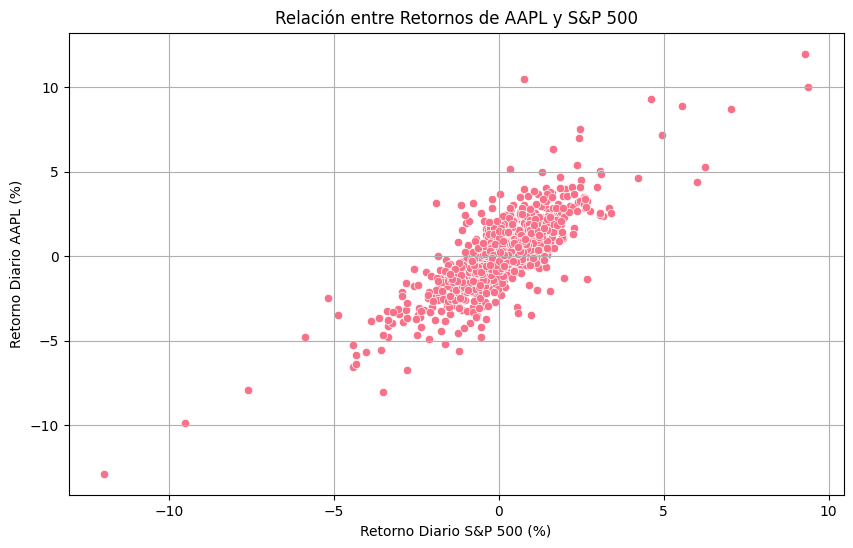

In [ ]:
# Visualizamos la relación entre los retornos
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SP500_Retorno', y='AAPL_Retorno', data=datos)
plt.title('Relación entre Retornos de AAPL y S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.grid(True)
plt.show()

In [ ]:
# Preparar datos para el modelo
X = datos[['SP500_Retorno']]  # Variable independiente (retorno del mercado)
y = datos['AAPL_Retorno']     # Variable dependiente (retorno de AAPL)

In [ ]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predecir con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nResultados del Modelo de Regresión Lineal:")
print(f"Coeficiente (Beta1): {modelo.coef_[0]:.4f}")
print(f"Intercepto (Beta0): {modelo.intercept_:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Resultados del Modelo de Regresión Lineal:
Coeficiente (Beta1): 1.2055
Intercepto (Beta0): 0.0775
Error Cuadrático Medio (MSE): 1.5980
Coeficiente de Determinación (R²): 0.6595


In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:           AAPL_Retorno   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     1603.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          2.03e-193
Time:                        00:07:21   Log-Likelihood:                -1295.9
No. Observations:                 804   AIC:                             2596.
Df Residuals:                     802   BIC:                             2605.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0775      0.043      1.810

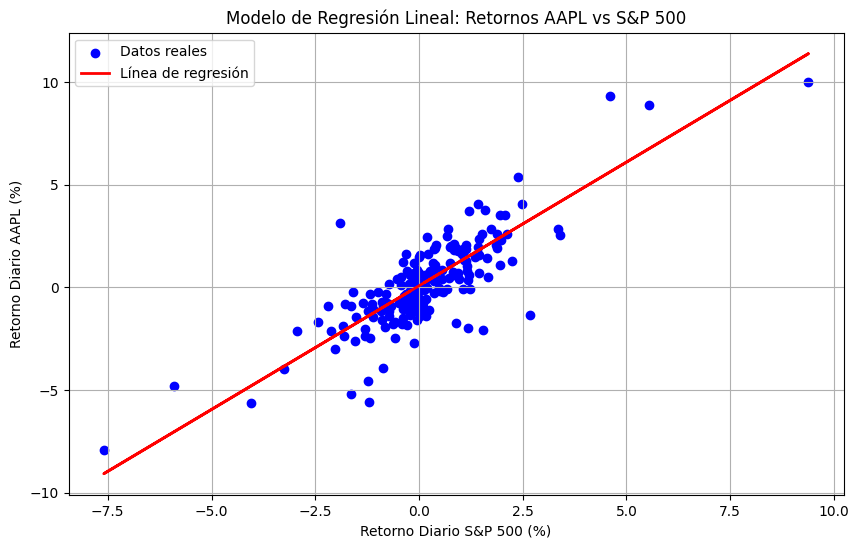

In [ ]:
# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Modelo de Regresión Lineal: Retornos AAPL vs S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.legend()
plt.grid(True)
plt.show()

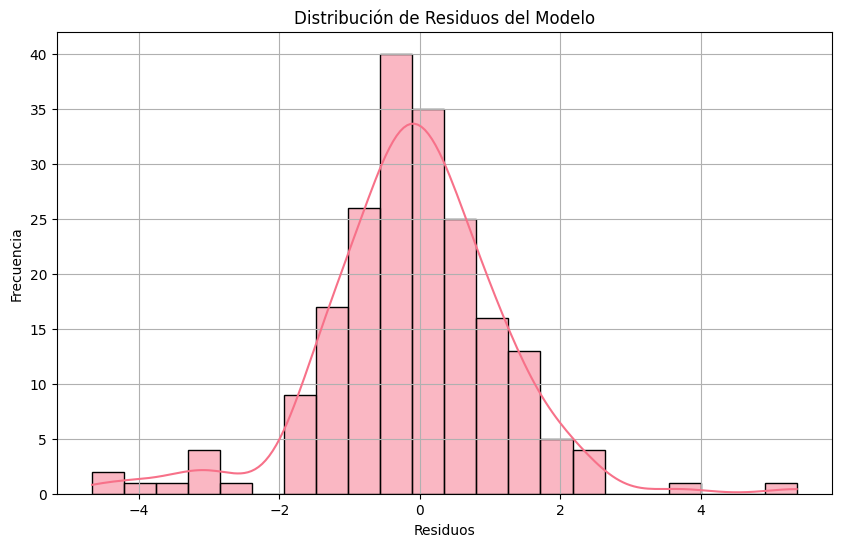

In [ ]:
# Análisis de residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos del Modelo')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

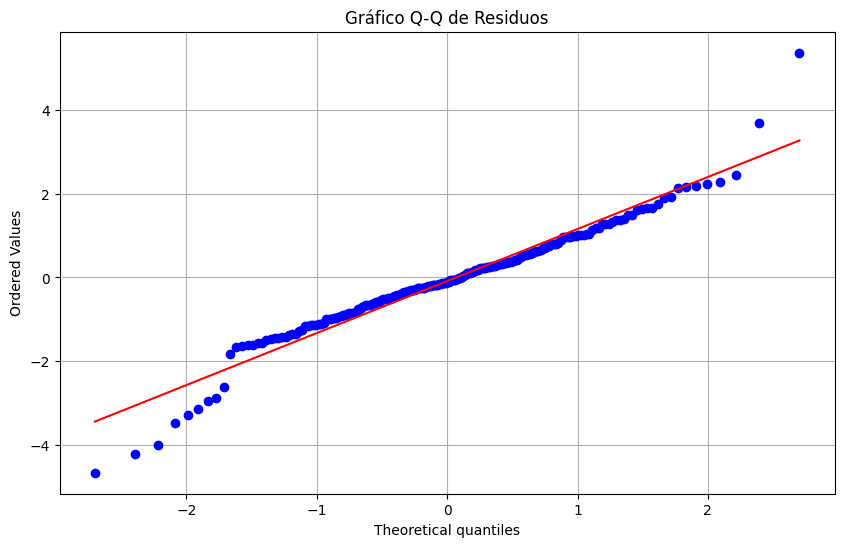

In [ ]:
# Gráfico Q-Q para normalidad de residuos
import scipy.stats as stats
plt.figure(figsize=(10, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')
plt.grid(True)
plt.show()

Ejemplo 2

---



In [ ]:
#Paso 1
# Importamos las librerías que vamos a utilizar
import numpy as np #para usar arrays y hacer operaciones matemáticas
import pandas as pd #para manipulación y análisis de datos
import seaborn as sb #para graficar
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
from sklearn.linear_model import LinearRegression #para implementar el modelo de regresión lineal
from sklearn.model_selection import train_test_split #para dividir tus datos en conjuntos de entrenamiento y prueba
import matplotlib.pyplot as plt #para graficar
from matplotlib.pyplot import subplots #para armar múltiples gráficos en uno
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF #para calcular el factor de inflación de la varianza
from sklearn.metrics import mean_squared_error, r2_score


El dataset Carseats contiene datos simulados sobre las ventas de asientos para niños en 400 tiendas diferentes. Este conjunto de datos incluye las siguientes variables:

Sales: Ventas unitarias (en miles) en cada ubicación.

CompPrice: Precio cobrado por el competidor en cada ubicación.

Income: Nivel de ingresos de la comunidad (en miles de dólares).

Advertising: Presupuesto de publicidad local para la empresa en cada ubicación (en miles de dólares).

Population: Tamaño de la población en la región (en miles).

Price: Precio que la empresa cobra por los asientos para niños en cada sitio.

ShelveLoc: Calidad de la ubicación en los estantes para los asientos (con niveles: Malo, Bueno y Medio).

Age: Edad promedio de la población local.

Education: Nivel educativo en cada ubicación.

Urban: Indicador de si la tienda está en una zona urbana o rural.

US: Indicador de si la tienda está en los EE. UU. o no.

In [ ]:
#Cargamos el conjunto de datos
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
datos = pd.read_csv(url)
datos

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [ ]:
#Creamos el modelo
#definimos la variable explicativa (precio)y explicada (ventas)

#Creamos un DataFrame con 2 columnas (una que contiene unos "intercepto")
#la otra columna contiene los valores de "Price" del archivo original
X = pd.DataFrame({'intercepto': np.ones(datos.shape[0]),
                  'Price':datos['Price']})
X

,intercepto,Price
0,1.0,120
1,1.0,83
2,1.0,80
3,1.0,97
4,1.0,128
...,...,...
395,1.0,128
396,1.0,120
397,1.0,159
398,1.0,95


In [ ]:
#se deterima la variable dependiente
y =datos['Sales']
#ajustamos el modelo, se crea un objeto de modelo lineal con X,Y
modelo= sm.OLS(y, X)
#ajusta el modelo a los datos y almacena los resultados en la variable"resultados"
resultados = modelo.fit()

#vemos los resultados
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     98.25
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           7.62e-21
Time:                        00:07:21   Log-Likelihood:                -938.23
No. Observations:                 400   AIC:                             1880.
Df Residuals:                     398   BIC:                             1888.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercepto    13.6419      0.633     21.558      0.0

/tmp/ipykernel_5008/3036822999.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[0],
/tmp/ipykernel_5008/3036822999.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[1],


Text(0.5, 0, 'Precio')

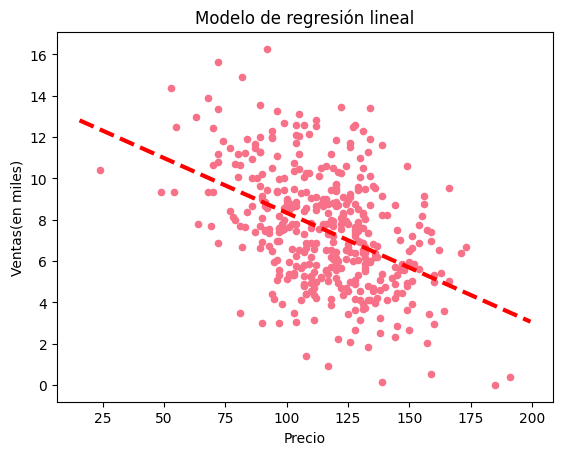

In [ ]:
#Graficamos:

#creamos una función
def abline(ax, b, m, *args, **kwargs):
    "Agrega una recta con pendiente m y un intercepto b a un objeto ax"
    xlim = ax.get_xlim() #obtenemos el límite del eje x
    ylim = [m * xlim[0] + b, m * xlim[1] + b] #calcula los límites del eje y
    ax.plot(xlim, ylim, *args, **kwargs)

ax = datos.plot.scatter('Price', 'Sales')
abline(ax,
       resultados.params[0],
       resultados.params[1],
       'r--', linewidth=3)
ax.set_title("Modelo de regresión lineal")
ax.set_ylabel("Ventas(en miles)")
ax.set_xlabel("Precio")


In [ ]:
#Establecemos una semilla aleatoria para garantizar la reproducibilidad de los resultados
np.random.seed(42)

In [ ]:
# Seleccionamos la variable Price como predictor y la variable Sales como variable de respuesta
X = datos["Price"].values.reshape(-1, 1)
Y = datos["Sales"]

In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predecimos el valor medio de las ventas para un valor de Precio dado
X_new = np.array([[50], [100], [150], [200], [250]])
y_pred = model.predict(X_new)
print("Predicciones:", y_pred)

Predicciones: [10.90665313  8.26750149  5.62834985  2.9891982   0.35004656]


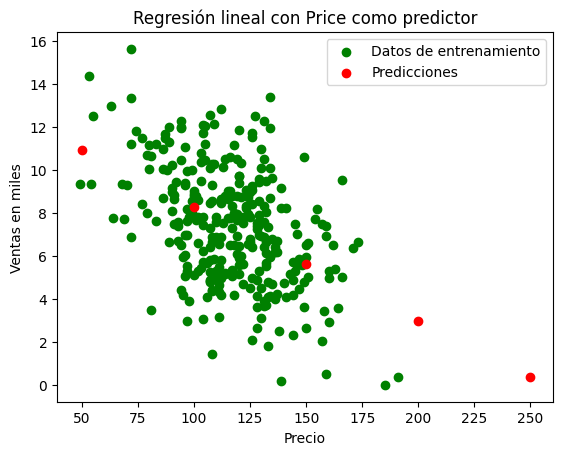

In [ ]:
# Visualizamos los resultados del modelo
plt.scatter(X_train, Y_train, color='green', label='Datos de entrenamiento')
plt.scatter(X_new, y_pred, color='red', label='Predicciones')
plt.xlabel('Precio')
plt.ylabel('Ventas en miles')
plt.title('Regresión lineal con Price como predictor')
plt.legend()
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     78.57
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           7.18e-17
Time:                        00:07:22   Log-Likelihood:                -692.75
No. Observations:                 300   AIC:                             1390.
Df Residuals:                     298   BIC:                             1397.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5458      0.708     19.136      0.0

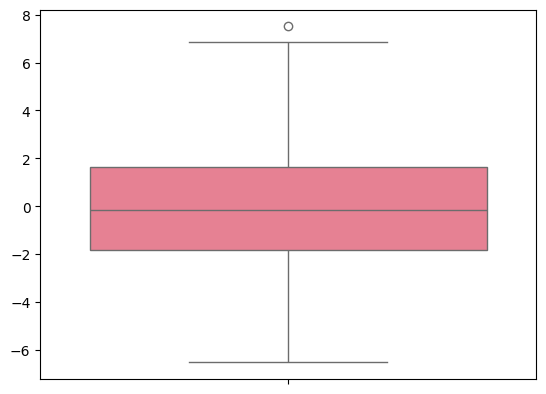

In [ ]:
#vemos la distribución de los residuos con un Boxplot

sb.boxplot(data=resultados.resid)
plt.ticklabel_format(style="plain",axis="y")

Ejemplo 3 - Regresión múltiple

---



In [ ]:
#MODELO DE REGRESIÓN MÚLTIPLE

# Seleccionamos las variables explicativas 'Price', 'Advertising', 'Income'y 'Population'
X = datos[['Price', 'Advertising', 'Income', 'Population']]

# Seleccionamos la variable explicada 'sales'
Y = datos['Sales']

In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Imprimimos los coeficientes del modelo
print("Coeficientes del modelo:", model.coef_)

Coeficientes del modelo: [-0.05268799  0.12301694  0.00599227  0.00032507]


In [ ]:
# Predecimos el valor medio de las ventas
Y_pred = model.predict(X_test)
Y_pred

array([ 9.0909035 ,  6.51480686,  7.43373648,  6.37496984,  6.96982148,
        6.03928811,  9.13008538,  9.06192804,  8.49175415,  5.9133342 ,
        6.4342246 ,  8.20773813,  8.33095338,  6.54610154,  6.78615463,
       11.40490644,  5.25703248, 10.20108601,  6.27334018,  7.4775741 ,
        9.47455103,  5.97513346,  6.10795511,  6.95154979,  7.80560792,
        6.44416629,  8.29690359,  8.21114652,  7.62762479,  5.70557431,
        8.30820463,  8.49343507,  6.83549848,  6.6357776 ,  8.43293816,
        6.01884666,  7.1923115 ,  8.37825438,  7.07052959,  5.70497235,
        7.42602762,  5.25383662, 10.42363766,  8.17637496,  6.01926873,
        8.48008127,  7.97499777,  7.97625653,  6.15218938,  6.73143304,
       10.82640785,  8.0953965 ,  7.12346402,  9.43938385,  7.20265341,
        5.3832284 ,  7.12835054,  8.70256124,  8.26717468,  6.08200874,
        6.66123028,  7.897136  ,  9.51397128,  5.06389678,  6.61685409,
        7.73986308,  8.25295171,  7.07859966,  7.72804418,  8.55

In [ ]:
# Calculamos el error cuadrático medio y el coeficiente de determinación R^2 de las predicciones
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print("Error cuadrático medio:", mse)
print("Coeficiente de determinación R^2:", r2)

Error cuadrático medio: 6.964134463827586
Coeficiente de determinación R^2: 0.2441206769051294


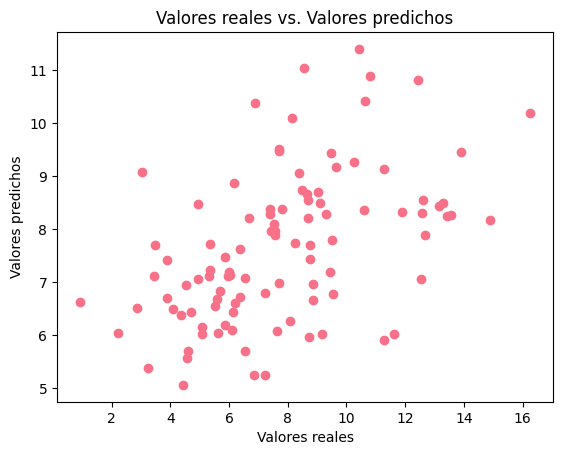

In [ ]:
# Graficamos los valores reales vs. los valores predichos
plt.scatter(Y_test, Y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. Valores predichos")
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     32.29
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           2.53e-22
Time:                        00:07:22   Log-Likelihood:                -673.39
No. Observations:                 300   AIC:                             1357.
Df Residuals:                     295   BIC:                             1375.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          12.2478      0.825     14.845      

Entrenamiento Supervisado

Predicción de categorías - Regresión logística

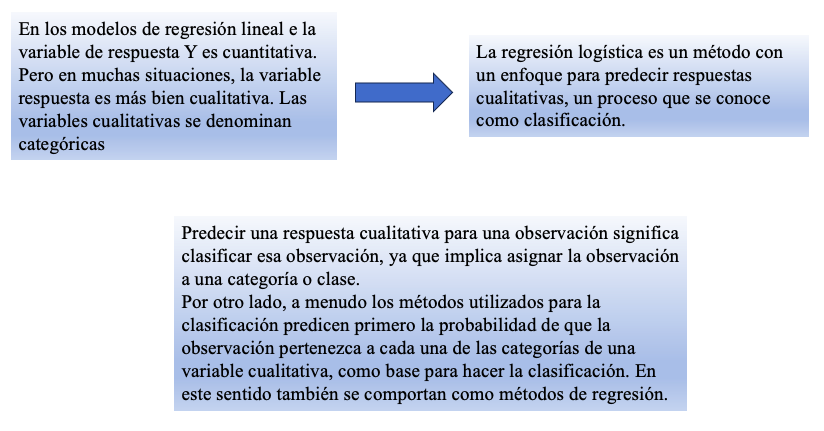

Ejemplo 4 - Regresión logística

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns  # Para visualizar la matriz de confusión

In [ ]:
# Cargar los datos
# Cargar el dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [ ]:
# Crear una nueva variable binaria para ventas altas/bajas
data['Ventas Altas'] = (data['Sales'] > data['Sales'].median()).astype(int)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Ventas Altas
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,1
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,0
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,0
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0


In [ ]:
# Seleccionar las variables predictoras y la variable objetivo
X = data[['Price', 'Advertising', 'Income', 'Population']]
y = data['Ventas Altas']

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ajustar el modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predecir las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)
Y_pred

array([ 9.0909035 ,  6.51480686,  7.43373648,  6.37496984,  6.96982148,
        6.03928811,  9.13008538,  9.06192804,  8.49175415,  5.9133342 ,
        6.4342246 ,  8.20773813,  8.33095338,  6.54610154,  6.78615463,
       11.40490644,  5.25703248, 10.20108601,  6.27334018,  7.4775741 ,
        9.47455103,  5.97513346,  6.10795511,  6.95154979,  7.80560792,
        6.44416629,  8.29690359,  8.21114652,  7.62762479,  5.70557431,
        8.30820463,  8.49343507,  6.83549848,  6.6357776 ,  8.43293816,
        6.01884666,  7.1923115 ,  8.37825438,  7.07052959,  5.70497235,
        7.42602762,  5.25383662, 10.42363766,  8.17637496,  6.01926873,
        8.48008127,  7.97499777,  7.97625653,  6.15218938,  6.73143304,
       10.82640785,  8.0953965 ,  7.12346402,  9.43938385,  7.20265341,
        5.3832284 ,  7.12835054,  8.70256124,  8.26717468,  6.08200874,
        6.66123028,  7.897136  ,  9.51397128,  5.06389678,  6.61685409,
        7.73986308,  8.25295171,  7.07859966,  7.72804418,  8.55

In [ ]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.775

In [ ]:
# Calcular e imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:\n', conf_matrix)

Matriz de confusión:
 [[30  7]
 [11 32]]


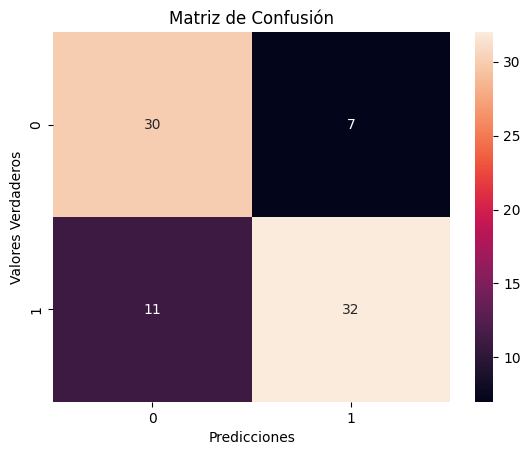

In [ ]:
# Visualizar la matriz de confusión usando Seaborn
sns.heatmap(conf_matrix, annot=True, fmt='g')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77        37
           1       0.82      0.74      0.78        43

    accuracy                           0.78        80
   macro avg       0.78      0.78      0.77        80
weighted avg       0.78      0.78      0.78        80



In [ ]:
#ver probabilidades predichas
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Obtener los coeficientes del modelo
coefficients = model.coef_[0]
intercept = model.intercept_[0]

print('Coefficients:')
for feature, coef in zip(X.columns, coefficients):
    print(f'{feature}: {coef}')
print(f'Intercept: {intercept}')

# Mostrar las probabilidades predichas
print('Predicted Probabilities:')
print(y_pred_prob)


Coefficients:
Price: -0.042755165507800404
Advertising: 0.09975422438836605
Income: 0.003172719722761881
Population: 0.0003070100514035633
Intercept: 3.947234726002689
Predicted Probabilities:
[0.79629205 0.30373153 0.49731602 0.29474308 0.40527067 0.24400283
 0.79315931 0.76914063 0.68050081 0.21323608 0.27774594 0.65333715
 0.65306572 0.32366845 0.34922971 0.95881814 0.12885001 0.90001481
 0.26654648 0.49291445 0.82889942 0.21644147 0.24241567 0.39569673
 0.55731068 0.31007033 0.64433305 0.65636056 0.51763481 0.18190584
 0.64000184 0.68673661 0.37568928 0.31872271 0.6718734  0.22697764
 0.45251415 0.65748484 0.40178817 0.19484704 0.48614035 0.13436786
 0.91166752 0.64494033 0.22555155 0.70155932 0.57332476 0.58518714
 0.25808922 0.33751527 0.93347828 0.63016709 0.43916733 0.82354298
 0.44451779 0.15207666 0.43244911 0.71143241 0.64049061 0.23626553
 0.31663077 0.57286402 0.83200139 0.12373297 0.31529314 0.54992875
 0.63248043 0.41557874 0.54883888 0.69005214 0.25352293 0.42672288
 0.

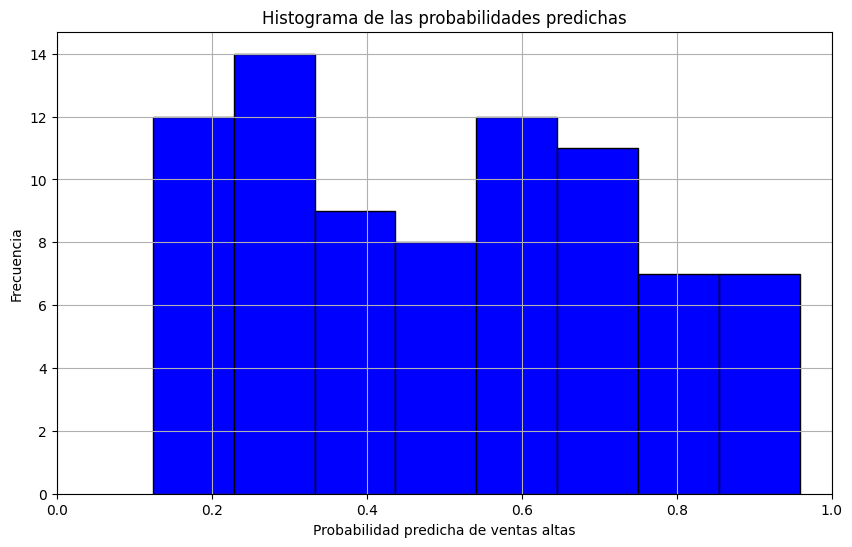

In [ ]:
# Crear un gráfico de las probabilidades predichas
# Obtener las probabilidades predichas
logit = LogisticRegression()
logit.fit(X_train, y_train)
prob = logit.predict_proba(X_test)
#armamos el gráfico

plt.figure(figsize=(10,6))
plt.hist(prob[:,1], bins=8, color='blue', edgecolor='black')
plt.xlim(0,1)
plt.title('Histograma de las probabilidades predichas')
plt.xlabel('Probabilidad predicha de ventas altas')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

Ejemplo 5 - Regresión logística

---



In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [ ]:
print(" Analizando riesgo ESG en tiempo real...")

# Lista de empresas con datos ESG disponibles
empresas = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Alphabet',
    'TSLA': 'Tesla',
    'JPM': 'JPMorgan',
    'XOM': 'Exxon Mobil',
    'JNJ': 'Johnson & Johnson',
    'WMT': 'Walmart',
    'NEE': 'NextEra Energy',
    'PG': 'Procter & Gamble'
}

# Descargar datos en tiempo real
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # Último año

risk_data = []

for ticker, name in empresas.items():
    try:
        # Descargar datos históricos
        stock = yf.Ticker(ticker)
        hist = stock.history(start=start_date, end=end_date)

        if len(hist) > 100:
            # Calcular métricas de riesgo (últimos 30 días)
            recent_data = hist.tail(30)

            # Volatilidad (desviación estándar de retornos diarios)
            returns = recent_data['Close'].pct_change().dropna()
            volatility = returns.std() * np.sqrt(252)  # Anualizada

            # Máximo drawdown
            cumulative = (1 + returns).cumprod()
            peak = cumulative.expanding(min_periods=1).max()
            drawdown = (cumulative - peak) / peak
            max_drawdown = drawdown.min()

            # Ratio de Sharpe (simplificado, asumiendo risk-free rate 0)
            sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0

            # Obtener precio actual
            current_price = stock.history(period='1d')['Close'].iloc[-1]

            # Score ESG aproximado (basado en datos públicos conocidos)
            # de datos de Sustainalytics/MSCI
            esg_scores = {
                'AAPL': 83, 'MSFT': 87, 'GOOGL': 85, 'TSLA': 68,
                'JPM': 72, 'XOM': 45, 'JNJ': 86, 'WMT': 76,
                'NEE': 92, 'PG': 79
            }
            esg_score = esg_scores.get(ticker, 50)

            risk_data.append({
                'Ticker': ticker,
                'Empresa': name,
                'Precio_Actual': current_price,
                'Volatilidad': volatility,
                'Max_Drawdown': abs(max_drawdown),
                'Sharpe_Ratio': sharpe_ratio,
                'ESG_Score': esg_score,
                'Fecha_Analisis': datetime.now()
            })

            print(f" {ticker}: V={volatility:.3f}, D={abs(max_drawdown):.2%}, S={sharpe_ratio:.2f}, ESG={esg_score}")

    except Exception as e:
        print(f" Error con {ticker}: {e}")

# Crear DataFrame
df_risk = pd.DataFrame(risk_data)

 Analizando riesgo ESG en tiempo real...
 AAPL: V=0.222, D=7.82%, S=1.28, ESG=83
 MSFT: V=0.346, D=17.72%, S=-2.00, ESG=87
 GOOGL: V=0.289, D=11.43%, S=-2.54, ESG=85
 TSLA: V=0.482, D=14.30%, S=0.13, ESG=68
 JPM: V=0.249, D=3.45%, S=2.12, ESG=72
 XOM: V=0.319, D=13.42%, S=-1.16, ESG=45
 JNJ: V=0.199, D=4.34%, S=2.17, ESG=86
 WMT: V=0.308, D=15.75%, S=-2.51, ESG=76
 NEE: V=0.263, D=12.56%, S=-3.15, ESG=92
 PG: V=0.232, D=4.95%, S=0.78, ESG=79


In [ ]:
# Definir riesgo alto/bajo basado en percentiles
df_risk['Riesgo_Alto'] = (df_risk['Volatilidad'] > df_risk['Volatilidad'].quantile(0.7)) | \
                         (df_risk['Max_Drawdown'] > df_risk['Max_Drawdown'].quantile(0.7)) | \
                         (df_risk['ESG_Score'] < df_risk['ESG_Score'].quantile(0.3))

df_risk['Riesgo_Alto'] = df_risk['Riesgo_Alto'].astype(int)

In [ ]:
# Entrenar modelo de Regresión Logística
X = df_risk[['Volatilidad', 'Max_Drawdown', 'Sharpe_Ratio', 'ESG_Score']]
y = df_risk['Riesgo_Alto']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(random_state=42)
model.fit(X_scaled, y)

LogisticRegression(random_state=42)

In [ ]:
# Predecir probabilidades
probabilities = model.predict_proba(X_scaled)[:, 1]
df_risk['Prob_Riesgo_Alto'] = probabilities

# Clasificar
df_risk['Prediccion'] = (probabilities > 0.5).astype(int)
df_risk['Categoria'] = df_risk['Prediccion'].map({0: 'Bajo Riesgo', 1: 'Alto Riesgo'})

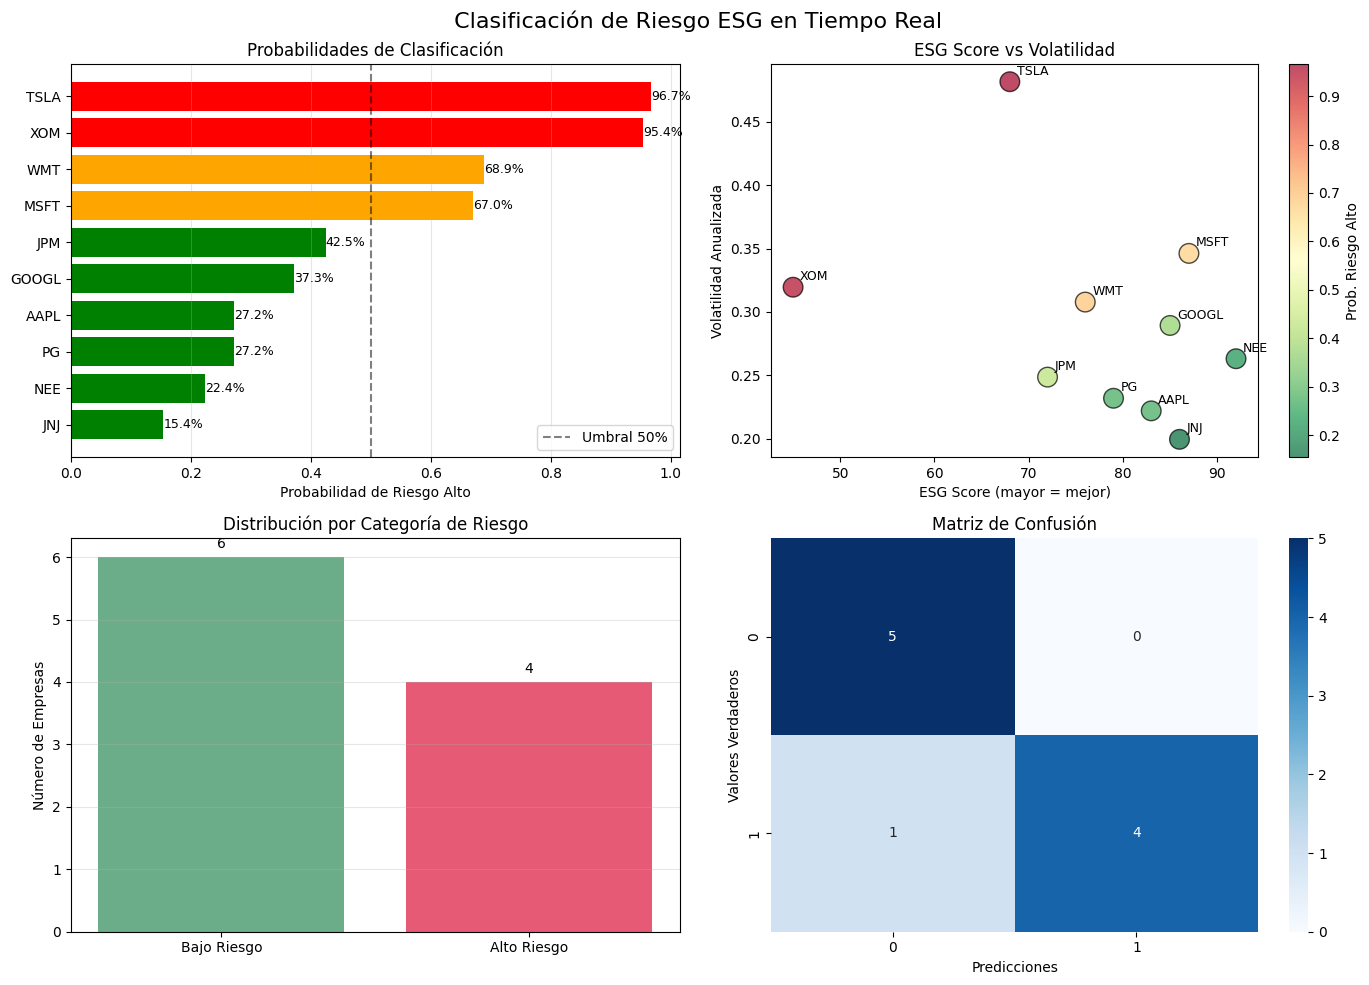


 REPORTE DE CLASIFICACIÓN DE RIESGO ESG
Fecha de análisis: 2026-06-18 00:07:28
Total empresas analizadas: 10

  EMPRESAS DE ALTO RIESGO (4):
  • TSLA (Tesla): 96.7%
  • XOM (Exxon Mobil): 95.4%
  • WMT (Walmart): 68.9%
  • MSFT (Microsoft): 67.0%

 EMPRESAS DE BAJO RIESGO (6):
  • JNJ (Johnson & Johnson): 15.4%
  • NEE (NextEra Energy): 22.4%
  • PG (Procter & Gamble): 27.2%
  • AAPL (Apple): 27.2%
  • GOOGL (Alphabet): 37.3%
  • JPM (JPMorgan): 42.5%

 ESTADÍSTICAS DEL MODELO:
  Precisión (train): 90.0%
  Coeficientes: Vol=0.810, Drawdown=0.539
               Sharpe=0.255, ESG=-0.904

 RECOMENDACIONES PARA INVERSIÓN SUSTENTABLE:
  1. Priorizar empresas con ESG Score > 80 y volatilidad < 0.3
  2. Diversificar entre sectores para mitigar riesgo específico
  3. Monitorear regularmente cambios en scores ESG


In [ ]:
# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' Clasificación de Riesgo ESG en Tiempo Real', fontsize=16)

# Gráfico 1: Probabilidades de riesgo
df_sorted = df_risk.sort_values('Prob_Riesgo_Alto', ascending=True)
colors = ['green' if p < 0.5 else 'orange' if p < 0.7 else 'red' for p in df_sorted['Prob_Riesgo_Alto']]
bars = axes[0, 0].barh(df_sorted['Ticker'], df_sorted['Prob_Riesgo_Alto'], color=colors)
axes[0, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 50%')
axes[0, 0].set_xlabel('Probabilidad de Riesgo Alto')
axes[0, 0].set_title('Probabilidades de Clasificación')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Añadir valores
for bar in bars:
    width = bar.get_width()
    axes[0, 0].text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1%}', ha='left', va='center', fontsize=9)

# Gráfico 2: ESG Score vs Volatilidad
scatter = axes[0, 1].scatter(df_risk['ESG_Score'], df_risk['Volatilidad'],
                     c=df_risk['Prob_Riesgo_Alto'], cmap='RdYlGn_r',
                     s=200, alpha=0.7, edgecolors='black')

# Etiquetar puntos
for idx, row in df_risk.iterrows():
    axes[0, 1].annotate(row['Ticker'], (row['ESG_Score'], row['Volatilidad']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

axes[0, 1].set_xlabel('ESG Score (mayor = mejor)')
axes[0, 1].set_ylabel('Volatilidad Anualizada')
axes[0, 1].set_title('ESG Score vs Volatilidad')
fig.colorbar(scatter, ax=axes[0, 1], label='Prob. Riesgo Alto')

# Gráfico 3: Distribución por categoría
category_counts = df_risk['Categoria'].value_counts()
colors_cat = ['#2E8B57', '#DC143C']
bars_cat = axes[1, 0].bar(category_counts.index, category_counts.values, color=colors_cat, alpha=0.7)
axes[1, 0].set_ylabel('Número de Empresas')
axes[1, 0].set_title('Distribución por Categoría de Riesgo')
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar in bars_cat:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom')

# Gráfico 4: Matriz de Confusión
conf_matrix_ex5 = confusion_matrix(y, df_risk['Prediccion'])
sns.heatmap(conf_matrix_ex5, annot=True, fmt='g', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión')
axes[1, 1].set_xlabel('Predicciones')
axes[1, 1].set_ylabel('Valores Verdaderos')

plt.tight_layout()
plt.show()

# Análisis detallado
print("\n" + "="*70)
print(" REPORTE DE CLASIFICACIÓN DE RIESGO ESG")
print("="*70)
print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total empresas analizadas: {len(df_risk)}")

# Empresas de alto riesgo
high_risk = df_risk[df_risk['Prediccion'] == 1]
print(f"\n  EMPRESAS DE ALTO RIESGO ({len(high_risk)}):")
for _, row in high_risk.sort_values('Prob_Riesgo_Alto', ascending=False).iterrows():
    print(f"  • {row['Ticker']} ({row['Empresa']}): {row['Prob_Riesgo_Alto']:.1%}")

# Empresas de bajo riesgo
low_risk = df_risk[df_risk['Prediccion'] == 0]
print(f"\n EMPRESAS DE BAJO RIESGO ({len(low_risk)}):")
for _, row in low_risk.sort_values('Prob_Riesgo_Alto').iterrows():
    print(f"  • {row['Ticker']} ({row['Empresa']}): {row['Prob_Riesgo_Alto']:.1%}")

# Estadísticas del modelo
print(f"\n ESTADÍSTICAS DEL MODELO:")
print(f"  Precisión (train): {model.score(X_scaled, y):.1%}")
print(f"  Coeficientes: Vol={model.coef_[0][0]:.3f}, Drawdown={model.coef_[0][1]:.3f}")
print(f"               Sharpe={model.coef_[0][2]:.3f}, ESG={model.coef_[0][3]:.3f}")

# Recomendaciones
print(f"\n RECOMENDACIONES PARA INVERSIÓN SUSTENTABLE:")
print("  1. Priorizar empresas con ESG Score > 80 y volatilidad < 0.3")
print("  2. Diversificar entre sectores para mitigar riesgo específico")
print("  3. Monitorear regularmente cambios en scores ESG")

Ejemplo 6 - Ramdom forest

---



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns

In [ ]:
# Datos simulados basados en datos reales de Sustainalytics
np.random.seed(42)
n_companies = 100

# Características financieras y ESG
data = {
    'market_cap': np.random.lognormal(20, 1, n_companies),
    'roa': np.random.normal(0.08, 0.05, n_companies),
    'debt_ratio': np.random.beta(2, 5, n_companies),
    'carbon_intensity': np.random.exponential(0.5, n_companies),
    'board_diversity': np.random.beta(3, 3, n_companies),
    'employee_satisfaction': np.random.beta(5, 2, n_companies),
    'controversy_score': np.random.beta(2, 5, n_companies)  # 0=bajo, 1=alto
}

df_esg = pd.DataFrame(data)

# Target: Score ESG (1-100)
df_esg['esg_score'] = (
    30 * (1 - df_esg['carbon_intensity']) +
    25 * df_esg['board_diversity'] +
    25 * df_esg['employee_satisfaction'] +
    20 * (1 - df_esg['controversy_score']) +
    np.random.normal(0, 5, n_companies)
)
df_esg['esg_score'] = np.clip(df_esg['esg_score'], 10, 90)

# Clasificación ESG
df_esg['esg_rating'] = pd.cut(df_esg['esg_score'],
                              bins=[0, 25, 50, 75, 100],
                              labels=['D', 'C', 'B', 'A'])

In [ ]:
df_esg

,market_cap,roa,debt_ratio,carbon_intensity,board_diversity,employee_satisfaction,controversy_score,esg_score,esg_rating
0,7.972781e+08,0.009231,0.266293,0.075279,0.501064,0.775544,0.016587,82.872353,A
1,4.225151e+08,0.058968,0.132445,0.793025,0.718311,0.831144,0.324444,56.279309,B
2,9.272081e+08,0.062864,0.113577,0.112590,0.270110,0.798228,0.246057,70.975151,B
3,2.225016e+09,0.039886,0.341559,0.089358,0.687894,0.588620,0.280407,72.326274,B
4,3.838823e+08,0.071936,0.169996,0.089722,0.773906,0.799616,0.250845,85.323529,A
...,...,...,...,...,...,...,...,...,...
95,1.122776e+08,0.099266,0.485751,0.002321,0.236637,0.682299,0.323479,70.918390,B
96,6.523686e+08,0.035807,0.223129,0.202857,0.076242,0.592233,0.259514,54.093231,B
97,6.298897e+08,0.087686,0.373449,0.253889,0.712892,0.825609,0.210734,72.175216,B
98,4.876524e+08,0.082910,0.386608,0.385442,0.493212,0.629752,0.445439,46.843008,C


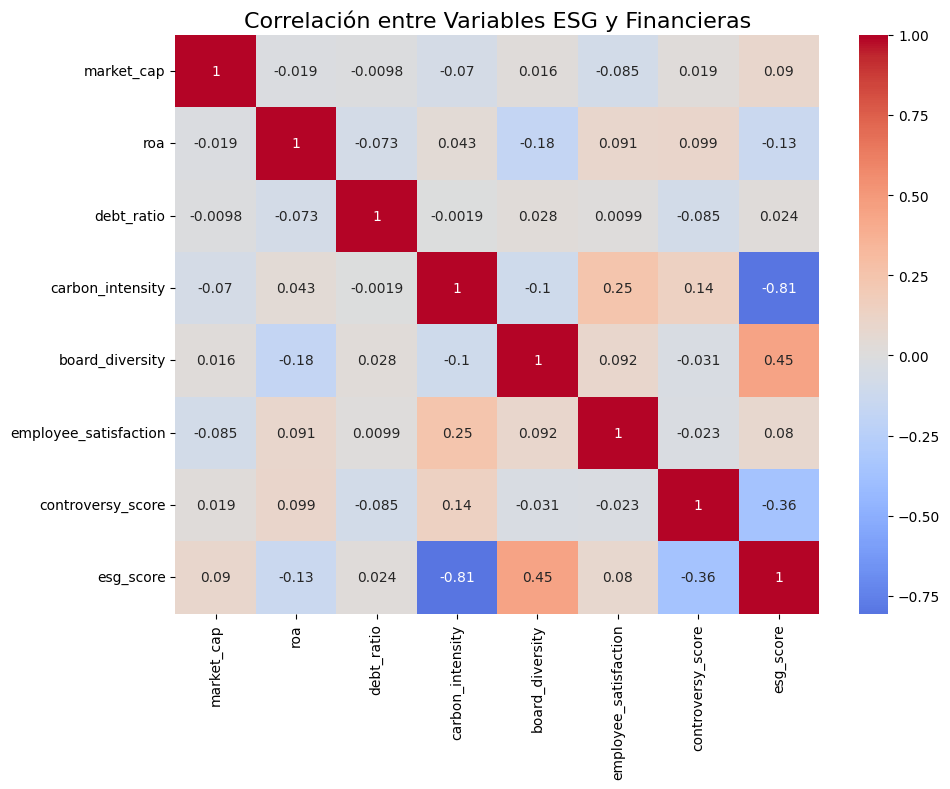

In [ ]:
# Visualización de correlaciones
plt.figure(figsize=(10, 8))
correlation_matrix = df_esg.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre Variables ESG y Financieras', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Modelo predictivo
X = df_esg[['market_cap', 'roa', 'debt_ratio', 'carbon_intensity',
            'board_diversity', 'employee_satisfaction', 'controversy_score']]
y = df_esg['esg_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predicciones
y_pred = model.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

MAE (Error Absoluto Medio): 5.70
R² Score: 0.76


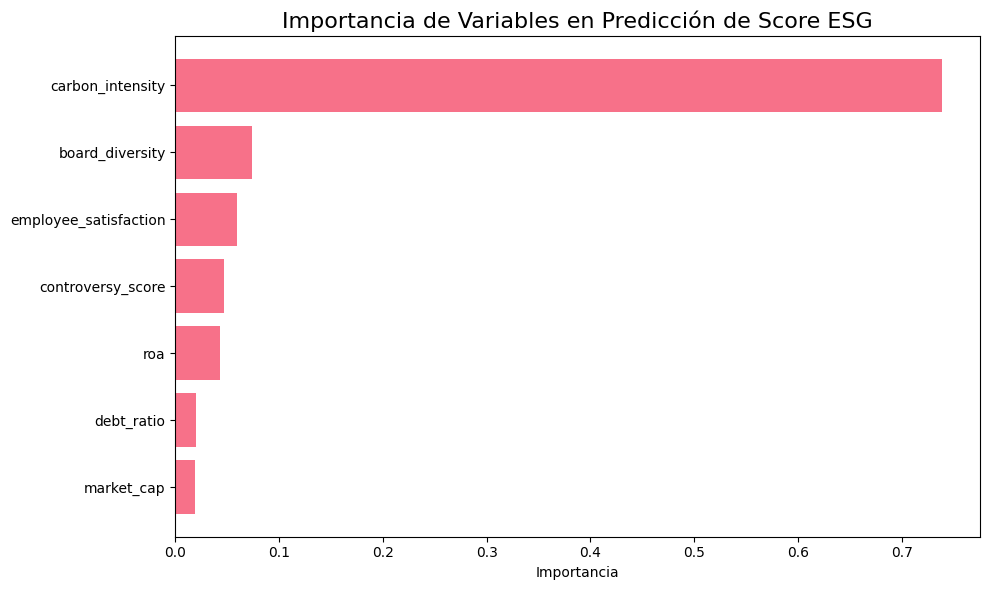

In [ ]:
# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Variables en Predicción de Score ESG', fontsize=16)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo de predicción
sample_company = X_test.iloc[0:1]
predicted_score = model.predict(sample_company)[0]
actual_score = y_test.iloc[0]

print(f"\nEjemplo de predicción:")
print(f"Score ESG real: {actual_score:.1f}")
print(f"Score ESG predicho: {predicted_score:.1f}")
print(f"Diferencia: {abs(predicted_score - actual_score):.1f}")



Ejemplo de predicción:
Score ESG real: 77.2
Score ESG predicho: 72.2
Diferencia: 5.0


Ejemplo 7 - Ramdom Forest para clasificación

---



In [ ]:
# 1. Crear una nueva columna en el DataFrame `df_esg` llamada 'High_ESG_Investment'.
# Asignar el valor 1 si 'esg_score' es mayor que 60, y 0 en caso contrario.
df_esg['High_ESG_Investment'] = (df_esg['esg_score'] > 60).astype(int)

# 2. Definir las características (X) para el modelo seleccionando las columnas especificadas.
X_cls = df_esg[['market_cap', 'roa', 'debt_ratio', 'carbon_intensity',
                'board_diversity', 'employee_satisfaction', 'controversy_score']]

# 3. Definir la variable objetivo (y) como la columna 'High_ESG_Investment'.
y_cls = df_esg['High_ESG_Investment']

# 4. Dividir los datos en conjuntos de entrenamiento y prueba con estratificación.
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

print("Data preparation for ESG classifier complete.")
print(f"Shape of X_train_cls: {X_train_cls.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of X_test_cls: {X_test_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")
print(f"Value counts for y_train_cls:\n{y_train_cls.value_counts()}")
print(f"Value counts for y_test_cls:\n{y_test_cls.value_counts()}")

Data preparation for ESG classifier complete.
Shape of X_train_cls: (75, 7)
Shape of y_train_cls: (75,)
Shape of X_test_cls: (25, 7)
Shape of y_test_cls: (25,)
Value counts for y_train_cls:
High_ESG_Investment
1    39
0    36
Name: count, dtype: int64
Value counts for y_test_cls:
High_ESG_Investment
1    13
0    12
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Crear una instancia de RandomForestClassifier con random_state=42.
rf_classifier = RandomForestClassifier(random_state=42)

# 2. Entrenar el modelo de RandomForestClassifier utilizando los datos de entrenamiento X_train_cls y y_train_cls.
rf_classifier.fit(X_train_cls, y_train_cls)

RandomForestClassifier(random_state=42)

Accuracy del RandomForestClassifier: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        12
           1       0.83      0.77      0.80        13

    accuracy                           0.80        25
   macro avg       0.80      0.80      0.80        25
weighted avg       0.80      0.80      0.80        25


Confusion Matrix:
[[10  2]
 [ 3 10]]


<Axes: >

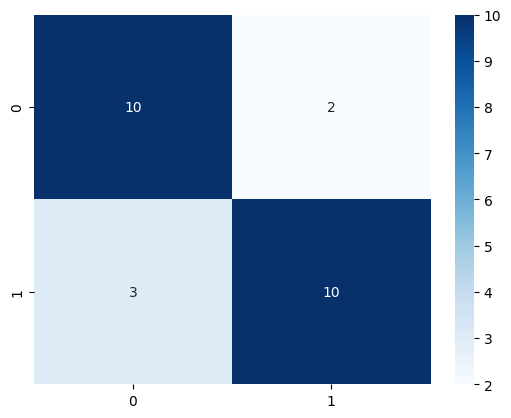

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Realizar predicciones sobre el conjunto de prueba
y_pred_cls = rf_classifier.predict(X_test_cls)

# 2. Calcular y ver la precisión del modelo
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy del RandomForestClassifier: {accuracy:.2f}")

# 3. Generar y ver el informe de clasificación detallado
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

# 4. Calcular y ver la matriz de confusión
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)
print("\nConfusion Matrix:")
print(conf_matrix)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

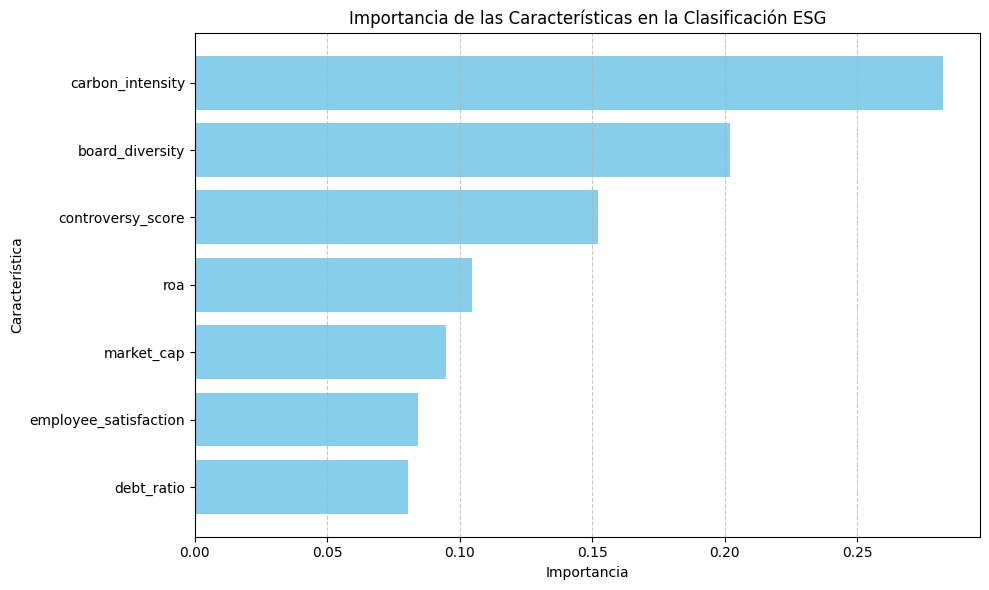

In [ ]:
# 1. Obtener la importancia de las características del modelo rf_classifier.
feature_importances = rf_classifier.feature_importances_

# 2. Crear un DataFrame de pandas con dos columnas: 'Feature' y 'Importance'.
features_df = pd.DataFrame({
    'Feature': X_cls.columns,
    'Importance': feature_importances
})

# 3. Ordenar el DataFrame de importancia de características en orden descendente.
features_df = features_df.sort_values(by='Importance', ascending=True)

# 4. Crear un gráfico de barras horizontal para visualizar la importancia de las características.
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de las Características en la Clasificación ESG')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
